# Step 1: BERT-base-uncased — Zero-Shot Evaluation

**Task:** Use pre-trained BERT-base-uncased **without any fine-tuning** to classify text into:
- `0` = Normal
- `1` = Offensive  
- `2` = Hate

**Method:** Zero-shot classification via cosine similarity between text [CLS] embeddings and label description embeddings.

**Datasets:** HateXPlain + TweetEval (3-class unified, labels already aligned)

In [1]:
import sys
print(sys.executable)   # 应该是 C:\Users\chenf\AppData\Local\Programs\Python\Python312\python.exe
import torch
print(torch.__version__)  # 应该是 2.7.1
print(torch.cuda.is_available())

C:\ProgramData\anaconda3\python.exe
2.6.0+cu124
True


## 0. Install Dependencies

In [34]:
# Run once if needed
# !pip install transformers torch scikit-learn pandas numpy matplotlib seaborn

## 1. Imports

In [35]:
import os, gc
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_CUDNN_V8_API_ENABLED'] = '0'
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128'

import warnings
warnings.filterwarnings("ignore")

# Silence transformers beta/gamma and weight-init warnings
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from transformers import BertTokenizer, BertModel
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)

torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)
torch.backends.cuda.enable_math_sdp(True)
torch.backends.cudnn.enabled = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.6 GB


## 2. Load Datasets

In [36]:
HATEXPLAIN_PATH = '../dataset/6713-ass2-dataset/HateXPlain_data/'
TWEETEVAL_PATH  = '../dataset/6713-ass2-dataset/Tweeteval三类分/'

# HateXPlain
hx_test  = pd.read_csv(HATEXPLAIN_PATH + 'test.csv')
hx_test  = hx_test.rename(columns={'text': 'text'})

# TweetEval
te_test  = pd.read_csv(TWEETEVAL_PATH + 'test.csv')
te_test  = te_test.rename(columns={'comment': 'text'})

# Label mapping: 0=Normal, 1=Offensive, 2=Hate
LABEL_NAMES = {0: 'Normal', 1: 'Offensive', 2: 'Hate'}

print('HateXPlain test size:', len(hx_test))
print('TweetEval test size: ', len(te_test))
print('\nHateXPlain label distribution:')
print(hx_test['label'].value_counts().sort_index())
print('\nTweetEval label distribution:')
print(te_test['label'].value_counts().sort_index())

HateXPlain test size: 2012
TweetEval test size:  3830

HateXPlain label distribution:
label
0    814
1    575
2    623
Name: count, dtype: int64

TweetEval label distribution:
label
0    2338
1     240
2    1252
Name: count, dtype: int64


## 3. Load BERT-base-uncased

In [37]:
MODEL_NAME = 'bert-base-uncased'

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
model     = BertModel.from_pretrained(MODEL_NAME, attn_implementation="eager")
model     = model.to(device)
model.eval()

print(f'Loaded: {MODEL_NAME}')

Loaded: bert-base-uncased


## 4. Zero-Shot Classification via Cosine Similarity

**Approach:**
1. Encode each input text → get [CLS] embedding
2. Encode label descriptions → get label embeddings  
3. Assign label = argmax(cosine_similarity(text_emb, label_embs))

This requires no fine-tuning — purely uses BERT's pre-trained representations.

In [38]:
# Label descriptions — richer descriptions improve zero-shot performance
LABEL_DESCRIPTIONS = [
    "This is a normal, neutral, or positive comment.",         # 0 = Normal
    "This is an offensive or rude comment.",                   # 1 = Offensive
    "This is hate speech targeting a person or group."         # 2 = Hate
]

def get_cls_embedding(texts, batch_size=32):
    """Return [CLS] embeddings for a list of texts."""
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors='pt'
        ).to(device)
        with torch.no_grad():
            outputs = model(**encoded)
        cls_emb = outputs.last_hidden_state[:, 0, :]  # [CLS] token
        all_embeddings.append(cls_emb.cpu())
    return torch.cat(all_embeddings, dim=0)

# Pre-compute label embeddings (3 vectors)
label_embeddings = get_cls_embedding(LABEL_DESCRIPTIONS)  # shape: (3, 768)
label_embeddings = F.normalize(label_embeddings, dim=1)
print('Label embeddings shape:', label_embeddings.shape)

Label embeddings shape: torch.Size([3, 768])


In [39]:
def predict_zeroshot(texts):
    """Predict labels using cosine similarity to label descriptions."""
    text_embs = get_cls_embedding(list(texts))           # (N, 768)
    text_embs = F.normalize(text_embs, dim=1)
    sims      = text_embs @ label_embeddings.T           # (N, 3)
    preds     = sims.argmax(dim=1).numpy()               # (N,)
    return preds

## 5. Evaluate on HateXPlain Test Set

In [40]:
print('Running zero-shot prediction on HateXPlain...')
hx_preds  = predict_zeroshot(hx_test['text'].fillna(''))
hx_labels = hx_test['label'].values

hx_macro_f1 = f1_score(hx_labels, hx_preds, average='macro')
hx_accuracy = accuracy_score(hx_labels, hx_preds)

print(f'\n=== HateXPlain Results ===')
print(f'Accuracy:  {hx_accuracy:.4f}')
print(f'Macro F1:  {hx_macro_f1:.4f}')
print()
print(classification_report(
    hx_labels, hx_preds,
    target_names=['Normal', 'Offensive', 'Hate']
))

Running zero-shot prediction on HateXPlain...

=== HateXPlain Results ===
Accuracy:  0.4036
Macro F1:  0.3734

              precision    recall  f1-score   support

      Normal       0.47      0.60      0.53       814
   Offensive       0.30      0.34      0.32       575
        Hate       0.39      0.21      0.27       623

    accuracy                           0.40      2012
   macro avg       0.39      0.38      0.37      2012
weighted avg       0.40      0.40      0.39      2012



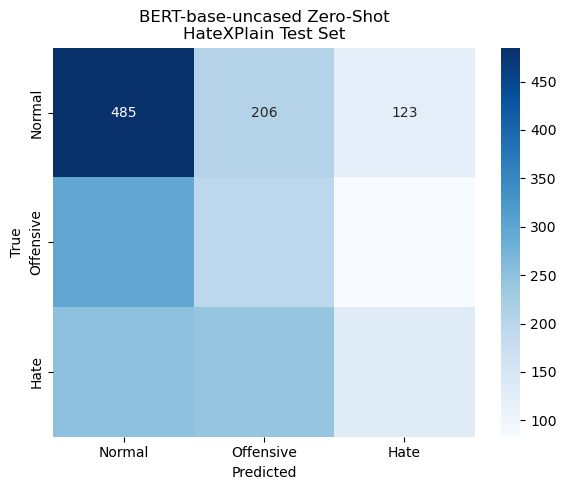

In [41]:
# Confusion Matrix — HateXPlain
cm = confusion_matrix(hx_labels, hx_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal', 'Offensive', 'Hate'],
    yticklabels=['Normal', 'Offensive', 'Hate']
)
plt.title('BERT-base-uncased Zero-Shot\nHateXPlain Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('bert_base_zeroshot_hatexplain_cm.png', dpi=150)
plt.show()

## 6. Evaluate on TweetEval Test Set

In [42]:
print('Running zero-shot prediction on TweetEval...')
te_preds  = predict_zeroshot(te_test['text'].fillna(''))
te_labels = te_test['label'].values

te_macro_f1 = f1_score(te_labels, te_preds, average='macro')
te_accuracy = accuracy_score(te_labels, te_preds)

print(f'\n=== TweetEval Results ===')
print(f'Accuracy:  {te_accuracy:.4f}')
print(f'Macro F1:  {te_macro_f1:.4f}')
print()
print(classification_report(
    te_labels, te_preds,
    target_names=['Normal', 'Offensive', 'Hate']
))

Running zero-shot prediction on TweetEval...

=== TweetEval Results ===
Accuracy:  0.4995
Macro F1:  0.2948

              precision    recall  f1-score   support

      Normal       0.65      0.77      0.70      2338
   Offensive       0.04      0.15      0.07       240
        Hate       0.39      0.07      0.11      1252

    accuracy                           0.50      3830
   macro avg       0.36      0.33      0.29      3830
weighted avg       0.53      0.50      0.47      3830



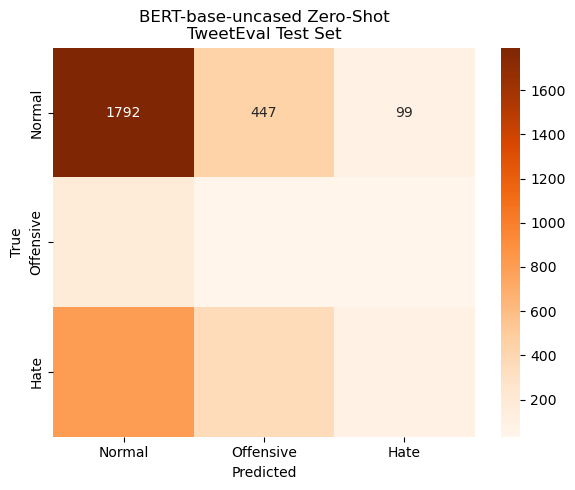

In [43]:
# Confusion Matrix — TweetEval
cm2 = confusion_matrix(te_labels, te_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm2, annot=True, fmt='d', cmap='Oranges',
    xticklabels=['Normal', 'Offensive', 'Hate'],
    yticklabels=['Normal', 'Offensive', 'Hate']
)
plt.title('BERT-base-uncased Zero-Shot\nTweetEval Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('bert_base_zeroshot_tweeteval_cm.png', dpi=150)
plt.show()

## 7. Summary Table

In [44]:
zs_results = pd.DataFrame({
    'Model':           ['BERT-base-uncased (zero-shot)', 'BERT-base-uncased (zero-shot)'],
    'Dataset':         ['HateXPlain', 'TweetEval'],
    'Accuracy':        [round(accuracy_score(hx_labels, hx_preds), 6),
                        round(accuracy_score(te_labels, te_preds), 6)],
    'Macro F1':        [round(f1_score(hx_labels, hx_preds, average='macro'), 6),
                        round(f1_score(te_labels, te_preds, average='macro'), 6)],
    'Macro Precision': [round(precision_score(hx_labels, hx_preds, average='macro', zero_division=0), 6),
                        round(precision_score(te_labels, te_preds, average='macro', zero_division=0), 6)],
    'Macro Recall':    [round(recall_score(hx_labels, hx_preds, average='macro', zero_division=0), 6),
                        round(recall_score(te_labels, te_preds, average='macro', zero_division=0), 6)],
})

print('=== Zero-shot BERT-base-uncased — Test Set Results ===')
print(zs_results.to_string(index=False))
zs_results.to_csv('bert_base_zeroshot_results.csv', index=False)
print('Saved: bert_base_zeroshot_results.csv')


=== Zero-shot BERT-base-uncased — Test Set Results ===
                        Model    Dataset  Accuracy  Macro F1  Macro Precision  Macro Recall
BERT-base-uncased (zero-shot) HateXPlain  0.403579  0.373412         0.387830      0.382322
BERT-base-uncased (zero-shot)  TweetEval  0.499478  0.294789         0.360472      0.329242
Saved: bert_base_zeroshot_results.csv


---
## 8. Fine-tuning BERT-base-uncased

Fine-tune BERT with a classification head on HateXPlain and TweetEval training sets.  
Evaluate with two label mappings:
- **binary**: Normal+Offensive → 0, Hate → 1
- **hateonly**: exclude Offensive, Normal → 0, Hate → 1

In [45]:
# ── Load train/val splits ────────────────────────────────
hx_train = pd.read_csv(HATEXPLAIN_PATH + 'train.csv')
hx_val   = pd.read_csv(HATEXPLAIN_PATH + 'val.csv')
te_train = pd.read_csv(TWEETEVAL_PATH  + 'train.csv').rename(columns={'comment': 'text'})
te_val   = pd.read_csv(TWEETEVAL_PATH  + 'val.csv').rename(columns={'comment': 'text'})

print('HateXPlain  train:', len(hx_train), '| val:', len(hx_val), '| test:', len(hx_test))
print('TweetEval   train:', len(te_train), '| val:', len(te_val), '| test:', len(te_test))

HateXPlain  train: 16093 | val: 2012 | test: 2012
TweetEval   train: 20916 | val: 2324 | test: 3830


In [46]:
from transformers import BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader

# ManualAdamW: bypasses PyTorch 2.6 fused optimizer CUDA kernel bug
class ManualAdamW:
    def __init__(self, params, lr=2e-5, betas=(0.9,0.999), eps=1e-8, weight_decay=0.01):
        self.params = [p for p in params if p.requires_grad]
        self.lr = lr; self.b1, self.b2 = betas; self.eps = eps; self.wd = weight_decay
        self.m = [torch.zeros_like(p.data) for p in self.params]
        self.v = [torch.zeros_like(p.data) for p in self.params]
        self.t = 0

    @torch.no_grad()
    def step(self):
        self.t += 1
        bc1 = 1.0 - self.b1**self.t; bc2 = 1.0 - self.b2**self.t
        for i, p in enumerate(self.params):
            if p.grad is None: continue
            g = p.grad
            p.mul_(1.0 - self.lr * self.wd)
            self.m[i].mul_(self.b1).add_(g, alpha=1.0 - self.b1)
            self.v[i].mul_(self.b2).addcmul_(g, g, value=1.0 - self.b2)
            p.addcdiv_(self.m[i]/bc1, (self.v[i]/bc2).sqrt().add_(self.eps), value=-self.lr)

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None: p.grad.zero_()

class HateSpeechDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = list(texts); self.labels = list(labels)
        self.tokenizer = tokenizer; self.max_len = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(str(self.texts[idx]), padding='max_length', truncation=True,
                             max_length=self.max_len, return_tensors='pt')
        return {'input_ids':      enc['input_ids'].squeeze(),
                'attention_mask': enc['attention_mask'].squeeze(),
                'token_type_ids': enc['token_type_ids'].squeeze(),
                'label': torch.tensor(self.labels[idx], dtype=torch.long)}

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    bar = tqdm(loader, desc='  train', leave=False, ncols=90)
    for batch in bar:
        optimizer.zero_grad()
        out = model(input_ids      = batch['input_ids'].to(device),
                    attention_mask = batch['attention_mask'].to(device),
                    token_type_ids = batch['token_type_ids'].to(device),
                    labels         = batch['label'].to(device))
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += out.loss.item()
        bar.set_postfix(loss=f'{out.loss.item():.3f}')
    return total_loss / len(loader)

def evaluate_model(model, loader):
    model.eval()
    preds_all, labels_all, losses = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc='  eval ', leave=False, ncols=90):
            labs = batch['label'].to(device)
            out  = model(input_ids      = batch['input_ids'].to(device),
                         attention_mask = batch['attention_mask'].to(device),
                         token_type_ids = batch['token_type_ids'].to(device),
                         labels         = labs)
            losses.append(out.loss.item())
            preds_all.extend(out.logits.argmax(dim=-1).cpu().numpy())
            labels_all.extend(batch['label'].numpy())
    preds = np.array(preds_all); labels = np.array(labels_all)
    return preds, labels, {
        'val_loss':        round(float(np.mean(losses)), 6),
        'accuracy':        round(accuracy_score(labels, preds), 6),
        'macro_f1':        round(f1_score(labels, preds, average='macro'), 6),
        'macro_precision': round(precision_score(labels, preds, average='macro', zero_division=0), 6),
        'macro_recall':    round(recall_score(labels, preds, average='macro', zero_division=0), 6),
    }

def prepare_3class(df):
    """Use all 3 classes: 0=Normal, 1=Offensive, 2=Hate."""
    return df.dropna(subset=['text', 'label']).reset_index(drop=True)

print('Helpers defined (ManualAdamW + tqdm + full metrics).')


Helpers defined (ManualAdamW + tqdm + full metrics).


In [47]:
# LR_CANDIDATES = [1e-5, 2e-5, 3e-5]
LR_CANDIDATES = [2e-5]
BATCH_SIZE = 8
EPOCHS     = 3

def run_finetune(train_df, val_df, dataset_name):
    train_bin = prepare_3class(train_df)
    val_bin   = prepare_3class(val_df)
    print(f'[{dataset_name}] 3-class  train:{len(train_bin)}  val:{len(val_bin)}')

    best_lr, best_val_f1, best_state, best_history = None, -1, None, None

    for lr in LR_CANDIDATES:
        print(f'  lr={lr}')
        ft_model = BertForSequenceClassification.from_pretrained(
            'bert-base-uncased', num_labels=3, attn_implementation='eager'
        ).to(device)
        optimizer    = ManualAdamW(ft_model.parameters(), lr=lr, weight_decay=0.01)
        train_loader = DataLoader(
            HateSpeechDataset(train_bin['text'], train_bin['label'], tokenizer),
            batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        val_loader   = DataLoader(
            HateSpeechDataset(val_bin['text'],   val_bin['label'],   tokenizer),
            batch_size=BATCH_SIZE, num_workers=0)

        history = []
        for ep in range(EPOCHS):
            train_loss = train_epoch(ft_model, train_loader, optimizer)
            _, _, m    = evaluate_model(ft_model, val_loader)
            history.append({'Epoch':            ep+1,
                            'Training Loss':    round(train_loss, 6),
                            'Validation Loss':  m['val_loss'],
                            'Accuracy':         m['accuracy'],
                            'Macro F1':         m['macro_f1'],
                            'Macro Precision':  m['macro_precision'],
                            'Macro Recall':     m['macro_recall']})
            print(f'    epoch {ep+1}/{EPOCHS}  train_loss={train_loss:.4f}  val_f1={m["macro_f1"]:.4f}')
            if device.type == 'cuda': torch.cuda.synchronize()
            torch.cuda.empty_cache()

        run_best_f1 = max(h['Macro F1'] for h in history)
        if run_best_f1 > best_val_f1:
            best_val_f1  = run_best_f1
            best_lr      = lr
            best_state   = {k: v.cpu().clone() for k, v in ft_model.state_dict().items()}
            best_history = history

        del ft_model; gc.collect(); torch.cuda.empty_cache()

    print(f'  -> Best lr={best_lr}  best_val_macro_f1={best_val_f1:.4f}')
    print(f'\n── Training Progress (lr={best_lr}, based on {dataset_name}) ──')
    print(pd.DataFrame(best_history).to_string(index=False))
    return best_state, best_lr, best_history

hx_best_state, hx_best_lr, hx_history = run_finetune(hx_train, hx_val, 'HateXplain')
te_best_state, te_best_lr, te_history = run_finetune(te_train, te_val, 'TweetEval')


[HateXplain] 3-class  train:16093  val:2012
  lr=2e-05


    epoch 1/3  train_loss=0.8296  val_f1=0.6637


    epoch 2/3  train_loss=0.6751  val_f1=0.6818


    epoch 3/3  train_loss=0.4984  val_f1=0.6512
  -> Best lr=2e-05  best_val_macro_f1=0.6818

── Training Progress (lr=2e-05, based on HateXplain) ──
 Epoch  Training Loss  Validation Loss  Accuracy  Macro F1  Macro Precision  Macro Recall
     1       0.829570         0.762369  0.662028  0.663693         0.674686      0.664118
     2       0.675062         0.752095  0.691849  0.681795         0.685115      0.679704
     3       0.498410         0.955263  0.668489  0.651220         0.651075      0.658114
[TweetEval] 3-class  train:20909  val:2323
  lr=2e-05


    epoch 1/3  train_loss=0.5560  val_f1=0.7257


    epoch 2/3  train_loss=0.3932  val_f1=0.7360


    epoch 3/3  train_loss=0.2848  val_f1=0.7250
  -> Best lr=2e-05  best_val_macro_f1=0.7360

── Training Progress (lr=2e-05, based on TweetEval) ──
 Epoch  Training Loss  Validation Loss  Accuracy  Macro F1  Macro Precision  Macro Recall
     1       0.556029         0.528824  0.770555  0.725662         0.738130      0.722532
     2       0.393243         0.571385  0.770125  0.736007         0.730833      0.743113
     3       0.284786         0.928810  0.754197  0.724976         0.712637      0.740080


In [48]:
def eval_test(best_state, test_df, dataset_name):
    test_bin = prepare_3class(test_df)
    model_ft = BertForSequenceClassification.from_pretrained(
        'bert-base-uncased', num_labels=3, attn_implementation='eager'
    )
    model_ft.load_state_dict(best_state)
    model_ft = model_ft.to(device)

    test_loader = DataLoader(
        HateSpeechDataset(test_bin['text'], test_bin['label'], tokenizer),
        batch_size=BATCH_SIZE, num_workers=0)
    preds, labels, m = evaluate_model(model_ft, test_loader)

    print(f'\n── {dataset_name} Test Classification Report ──')
    print(classification_report(labels, preds, target_names=['Normal', 'Offensive', 'Hate']))

    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal','Offensive','Hate'], yticklabels=['Normal','Offensive','Hate'])
    plt.title(f'BERT Fine-tuned\n{dataset_name} Test Set')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    fname = f'bert_finetune_{dataset_name.lower()}_cm.png'
    plt.savefig(fname, dpi=150); plt.close()
    print(f'Saved: {fname}')

    del model_ft; gc.collect(); torch.cuda.empty_cache()

    return {'Dataset':         dataset_name,
            'Mapping':         '3-class (Normal/Offensive/Hate)',
            'Accuracy':        m['accuracy'],
            'Macro F1':        m['macro_f1'],
            'Macro Precision': m['macro_precision'],
            'Macro Recall':    m['macro_recall'],
            'Weighted F1':     round(f1_score(labels, preds, average='weighted'), 6)}

rows = [eval_test(hx_best_state, hx_test, 'HateXplain'),
        eval_test(te_best_state, te_test, 'TweetEval')]

ft_results = pd.DataFrame(rows)
print('\n=== Fine-tuned BERT-base-uncased — Test Set Results ===')
print(ft_results.to_string(index=False))
ft_results.to_csv('bert_base_finetune_results.csv', index=False)
print('Saved: bert_base_finetune_results.csv')



── HateXplain Test Classification Report ──
              precision    recall  f1-score   support

      Normal       0.73      0.71      0.72       814
   Offensive       0.55      0.46      0.50       575
        Hate       0.67      0.80      0.73       623

    accuracy                           0.67      2012
   macro avg       0.65      0.66      0.65      2012
weighted avg       0.66      0.67      0.66      2012

Saved: bert_finetune_hatexplain_cm.png



── TweetEval Test Classification Report ──
              precision    recall  f1-score   support

      Normal       0.85      0.37      0.52      2338
   Offensive       0.37      0.46      0.41       240
        Hate       0.48      0.95      0.63      1252

    accuracy                           0.57      3830
   macro avg       0.56      0.60      0.52      3830
weighted avg       0.70      0.57      0.55      3830

Saved: bert_finetune_tweeteval_cm.png

=== Fine-tuned BERT-base-uncased — Test Set Results ===
   Dataset                         Mapping  Accuracy  Macro F1  Macro Precision  Macro Recall  Weighted F1
HateXplain 3-class (Normal/Offensive/Hate)  0.666501  0.650338         0.651033      0.656508     0.660822
 TweetEval 3-class (Normal/Offensive/Hate)  0.567363  0.521070         0.564835      0.595316     0.549332
Saved: bert_base_finetune_results.csv
